# Notebook 05 – XGBoost Machine Learning Model

This notebook trains an XGBoost classifier to predict gentrification pressure levels for Copenhagen neighborhoods.

**Key differences from OLD_05:**
- Target variable: `combined_class_idx` from `classified_combined.gpkg` (0=Low/gentrified, 1=Medium, 2=High)
- Input: GT_V3 only (trend + start/end values + volatility features)
- Future predictions for 2025, 2030, 2035 by linearly extrapolating `_end_value` features using `_reg_2015_2020` slopes

**Note on `first_low_period`:** This temporal field is computed and shown for analysis, but is **excluded from model training** to avoid label leakage (it is non-null only for class-0 clusters, which would perfectly reveal the target).

Predictions are saved in `results/models/`.

## 1. Imports & Configuration

In [140]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

In [172]:
# ── Configuration ────────────────────────────────────────────────────────────

# Paths
FEATURES_PATH       = "../data/raw/GT_V3_data.csv"
#COMBINED_GPK_PATH   = "../data/processed/classified_gt/classified_combined_consec2.gpkg"
COMBINED_GPK_PATH   = "../data/processed/classified_gt/classified_combined.gpkg" # change between different classified combined gpkg versions
RESULTS_DIR         = "../results/models"

# The 6 historical periods (in order)
PERIODS = ['1990_1995', '1995_2000', '2000_2005', '2005_2010', '2010_2015', '2015_2020']

# Base feature names (19 socio-economic indicators)
BASE_FEATURES = [
    'EMUB', 'PMB', 'PUB', 'age_18_25', 'age_26_40', 'age_41_55', 'age_56_69',
    'crime_main_y', 'disp_inc', 'emp', 'grund', 'gym_erhv', 'lvu',
    'mean_sqm', 'mig_in', 'mig_out', 'ool', 'public_housing', 'unemp'
]

# Future horizons: {year: years_ahead_from_2020}
FUTURE_HORIZONS = {2025: 5, 2030: 10, 2035: 15}

# Ordinal mapping for first_low_period
PERIOD_ORDINAL = {p: i+1 for i, p in enumerate(PERIODS)}  # 1990_1995→1 … 2015_2020→6

os.makedirs(RESULTS_DIR, exist_ok=True)
print("Configuration loaded.")
print("Period ordinal map:", PERIOD_ORDINAL)


Configuration loaded.
Period ordinal map: {'1990_1995': 1, '1995_2000': 2, '2000_2005': 3, '2005_2010': 4, '2010_2015': 5, '2015_2020': 6}


## 2. Load Data

In [173]:
def _ensure_cluster_id(df):
    """Normalize join key to 'cluster_id' regardless of original column name."""
    if 'cluster_id' in df.columns:
        return df
    matches = [c for c in df.columns if c.lower() == 'cluster_id']
    if matches:
        return df.rename(columns={matches[0]: 'cluster_id'})
    heur = [c for c in df.columns if ('cluster' in c.lower()) or ('munic' in c.lower())]
    if heur:
        print(f"INFO: Using '{heur[0]}' as 'cluster_id'")
        return df.rename(columns={heur[0]: 'cluster_id'})
    raise KeyError("No join key found. Expected 'cluster_id' or a column containing 'cluster'/'munic'.")

In [174]:
# Load GT_V2 features
data = pd.read_csv(FEATURES_PATH)
data = _ensure_cluster_id(data)
print(f"GT_V2 features loaded: {data.shape}")
data.head()

GT_V2 features loaded: (13519, 281)


,cluster_id,EMUB_reg_1990_1995,EMUB_reg_1995_2000,EMUB_reg_2000_2005,EMUB_reg_2005_2010,EMUB_reg_2010_2015,EMUB_reg_2015_2020,PMB_reg_1990_1995,PMB_reg_1995_2000,PMB_reg_2000_2005,...,public_housing_std_2000_2005,public_housing_std_2005_2010,public_housing_std_2010_2015,public_housing_std_2015_2020,unemp_std_1990_1995,unemp_std_1995_2000,unemp_std_2000_2005,unemp_std_2005_2010,unemp_std_2010_2015,unemp_std_2015_2020
0,101_1,28.597450,-29.508971,-8.305425,-10.737765,-18.739771,21.651561,1.006311,0.810537,1.273032,...,0.016733,0.024221,0.032863,0.010954,0.970788,0.688128,0.709598,0.880665,0.591041,1.302702
1,101_10,6.118231,-3.252824,3.160862,-1.795472,-7.849762,-7.569549,40.231621,-12.639138,4.562269,...,0.000000,0.000000,0.000000,0.000000,1.479157,1.042160,1.020804,2.021873,0.985894,1.197909
2,101_100,16.270826,-9.405488,1.413428,0.696864,9.424946,-1.370276,-25.301205,17.096774,24.903581,...,0.000000,0.000000,0.000000,0.000000,1.961616,4.803055,2.371906,2.198697,0.801758,0.870205
3,101_1000,18.296847,-0.560272,13.539355,-6.451128,-3.552484,-16.666667,35.381356,101.251956,-20.762053,...,0.000000,0.000000,0.000000,0.000000,2.798931,1.666957,1.241274,1.674763,1.326147,1.771727
4,101_1001,-4.456372,-2.743663,6.824288,-2.665996,3.165375,-4.946775,24.788136,-7.809847,-21.362799,...,0.052440,0.021370,0.013292,0.010954,0.732004,1.315502,0.468931,0.853534,0.415724,0.718192


In [175]:
# Load combined classification GeoPackage (target + first_low_period)
gdf_combined = gpd.read_file(COMBINED_GPK_PATH)
gdf_combined = _ensure_cluster_id(gdf_combined)

# Normalize the temporal column to 'first_low_period' regardless of source file
# (classified_combined uses 'first_low_period'; consec variants use 'first_consec_low_period')
if 'first_consec_low_period' in gdf_combined.columns and 'first_low_period' not in gdf_combined.columns:
    gdf_combined = gdf_combined.rename(columns={'first_consec_low_period': 'first_low_period'})

# Align cluster_id dtype to string (strip leading zeros / whitespace)
gdf_combined['cluster_id'] = gdf_combined['cluster_id'].astype(str).str.strip().str.lstrip('0')
data['cluster_id'] = data['cluster_id'].astype(str).str.strip().str.lstrip('0')

print(f"classified_combined loaded: {gdf_combined.shape}")
print("Columns:", list(gdf_combined.columns))
gdf_combined[['cluster_id', 'combined_class_idx', 'combined_class', 'first_low_period']].head()


classified_combined loaded: (2232, 9)
Columns: ['area', 'cluster_id', 'id_munic', 'munic_code', 'avg_mean', 'combined_class_idx', 'combined_class', 'first_low_period', 'geometry']


,cluster_id,combined_class_idx,combined_class,first_low_period
0,101_1,0,Low,2010_2020
1,101_2,1,Medium,None
2,101_3,0,Low,2010_2020
3,101_4,1,Medium,None
4,101_5,0,Low,2010_2020


In [176]:
# Keep only the columns we need from the GeoPackage
labels = gdf_combined[['cluster_id', 'combined_class_idx', 'combined_class', 'first_low_period']].copy()
labels = labels.drop_duplicates('cluster_id')

# Merge into feature data
n_before = len(data)
data = data.merge(labels, on='cluster_id', how='left')
missing_target = data['combined_class_idx'].isna().sum()
print(f"Merged: {len(data)} rows (was {n_before}). Missing target values: {missing_target}")

data[['cluster_id', 'combined_class_idx', 'combined_class', 'first_low_period']].head(10)

Merged: 13519 rows (was 13519). Missing target values: 11287


,cluster_id,combined_class_idx,combined_class,first_low_period
0,101_1,0.0,Low,2010_2020
1,101_10,0.0,Low,2010_2020
2,101_100,2.0,High,None
3,101_1000,0.0,Low,1990_2000
4,101_1001,2.0,High,None
5,101_1002,0.0,Low,1990_2000
6,101_1003,2.0,High,None
7,101_1004,0.0,Low,2000_2010
8,101_1005,2.0,High,None
9,101_1006,2.0,High,None


## 3. Temporality Feature Engineering

`first_low_period` records the earliest period a cluster was classified Low (gentrified). It is encoded as an ordinal integer (1–6) for inspection:
- `'1990_1995'` → 1, `'1995_2000'` → 2, ..., `'2015_2020'` → 6
- `None` / NaN (never classified Low) → 0

> **Important:** `first_low_period_encoded` is added to `data` for analysis purposes only.  
> It is **not included in the training feature matrix X** because it is non-zero exclusively for class-0 clusters, which constitutes label leakage and produces artificially perfect class-0 metrics.

In [177]:
data['first_low_period_encoded'] = (
    data['first_low_period']
    .map(PERIOD_ORDINAL)
    .fillna(0)
    .astype(int)
)

print("first_low_period_encoded distribution:")
print(data.groupby('combined_class_idx')['first_low_period_encoded'].value_counts().sort_index())

first_low_period_encoded distribution:
combined_class_idx  first_low_period_encoded
0.0                 0                           871
1.0                 0                           744
2.0                 0                           617
Name: count, dtype: int64


## 3b. Derived Feature Engineering

Two lightweight feature groups are added to enrich the feature matrix:

1. **Acceleration** (`{feat}_accel`): change in trend slope between the last two periods (`_reg_2015_2020 − _reg_2010_2015`). Captures whether a trend is speeding up or decelerating — a key signal for boundary-class neighborhoods.
2. **Total-change ratio** (`{feat}_total_change`): `end_value / (|start_value| + ε)`. Encodes the full 30-year magnitude of change, complementing the per-period slopes.


In [178]:
# ── Derived Features ─────────────────────────────────────────────────────────
eps = 1e-6

for feat in BASE_FEATURES:
    # 1. Acceleration: last-period slope minus previous-period slope
    col_last = f'{feat}_reg_2015_2020'
    col_prev = f'{feat}_reg_2010_2015'
    if col_last in data.columns and col_prev in data.columns:
        data[f'{feat}_accel'] = data[col_last] - data[col_prev]

    # 2. Total-change ratio: end / start (30-year magnitude)
    end_col   = f'{feat}_end_value'
    start_col = f'{feat}_start_value'
    if end_col in data.columns and start_col in data.columns:
        data[f'{feat}_total_change'] = data[end_col] / (data[start_col].abs() + eps)

accel_cols = [c for c in data.columns if c.endswith('_accel')]
tc_cols    = [c for c in data.columns if c.endswith('_total_change')]
print(f"Derived features added:")
print(f"  Acceleration features  (_accel):        {len(accel_cols)}")
print(f"  Total-change ratios    (_total_change): {len(tc_cols)}")


Derived features added:
  Acceleration features  (_accel):        19
  Total-change ratios    (_total_change): 19


## 4. Define X / y and Train-Val-Test Split

In [201]:
# Drop non-feature columns
DROP_COLS = {'cluster_id', 'combined_class_idx', 'combined_class', 'avg_mean',
             'first_low_period', 'first_low_period_encoded', 'geometry'}

# Drop rows where the target is missing (no match in classified_combined.gpkg)
n_before = len(data)
data = data.dropna(subset=['combined_class_idx']).copy()
n_dropped = n_before - len(data)
if n_dropped:
    print(f"[INFO] Dropped {n_dropped} rows with missing target (unmatched cluster_ids).")

X = data.drop(columns=[c for c in DROP_COLS if c in data.columns])
y = data['combined_class_idx'].astype(int)

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts().sort_index()}")
print(f"\n'first_low_period_encoded' excluded from X (leak prevention): {'first_low_period_encoded' not in X.columns}")


X shape: (2232, 318)
y distribution:
combined_class_idx
0    871
1    744
2    617
Name: count, dtype: int64

'first_low_period_encoded' excluded from X (leak prevention): True


In [202]:
# ── NaN Audit & Imputation ────────────────────────────────────────────────────
nan_rates = X.isna().mean().sort_values(ascending=False)
high_nan  = nan_rates[nan_rates > 0.5]

if len(high_nan):
    print(f"Dropping {len(high_nan)} columns with >50% NaN rate:")
    print(high_nan.round(3).to_string())
    X = X.drop(columns=high_nan.index.tolist())
else:
    print("No columns with >50% NaN rate.")

# Impute remaining NaNs with column median
remaining_nan = X.isna().sum().sum()
if remaining_nan:
    X = X.fillna(X.median())
    print(f"\nImputed {remaining_nan} remaining NaN cells with column median.")
else:
    print("No remaining NaNs — no imputation needed.")

print(f"\nX shape after NaN handling: {X.shape}")


Dropping 22 columns with >50% NaN rate:
mig_out_total_change            1.000
mean_price_reg_1990_1995        1.000
mig_in_total_change             1.000
mean_sqm_total_change           1.000
mig_out_start_value             1.000
mean_sqm_start_value            1.000
mean_price_start_value          1.000
mig_in_start_value              1.000
mig_out_reg_1990_1995           1.000
mig_in_reg_1990_1995            1.000
mean_sqm_reg_1990_1995          1.000
crime_main_y_accel              0.615
public_housing_reg_1990_1995    0.588
public_housing_reg_1995_2000    0.562
public_housing_reg_2000_2005    0.548
public_housing_reg_2005_2010    0.540
mean_sqm_std_1990_1995          0.522
mean_price_std_1990_1995        0.522
public_housing_accel            0.521
public_housing_reg_2015_2020    0.513
public_housing_reg_2010_2015    0.510
crime_main_y_reg_2015_2020      0.500

Imputed 27297 remaining NaN cells with column median.

X shape after NaN handling: (2232, 296)


In [203]:
# 60 / 20 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 1338, Val: 447, Test: 447


In [204]:
# Balanced sample weights — upweight rarer/harder classes during training
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sw_train = np.array([cw[yi] for yi in y_train])
print("Class weights (balanced):", {int(c): round(float(w), 3)
                                     for c, w in zip(np.unique(y_train), cw)})


Class weights (balanced): {0: 0.854, 1: 1.0, 2: 1.205}


## 4b. Feature Selection (Top-N by Importance)

With ~320 features and ~1000 training samples the model is in a high-variance / overfitting regime.  
A shallow XGBoost is fitted on `X_train` only (no leakage) to rank features, then only the top `N_FEATURES` are kept.  
`X_train`, `X_val`, `X_test`, and `X` are all narrowed to the same column set so all downstream cells work unchanged.


In [205]:
from sklearn.feature_selection import SelectFromModel

# ── How many features to keep ────────────────────────────────────────────────
N_FEATURES = 60   # tune: try 40, 60, 80; lower → less overfit, higher → more signal

# Fit a shallow model on train only (no val/test leakage)
_pre_clf = XGBClassifier(
    n_estimators=200, max_depth=4,
    random_state=42, n_jobs=-1, verbosity=0
)
_pre_clf.fit(X_train, y_train, sample_weight=sw_train)

selector = SelectFromModel(_pre_clf, max_features=N_FEATURES, prefit=True)
selected_cols = X_train.columns[selector.get_support()].tolist()

n_before = X_train.shape[1]
X_train = X_train[selected_cols].copy()
X_val   = X_val[selected_cols].copy()
X_test  = X_test[selected_cols].copy()
X       = X[selected_cols].copy()

print(f"Features reduced: {n_before} → {len(selected_cols)}")
print("\nSelected features:")
# Print sorted by importance
_fi = dict(zip(selected_cols, _pre_clf.feature_importances_[selector.get_support()]))
for name, imp in sorted(_fi.items(), key=lambda x: -x[1])[:20]:
    print(f"  {name:<40s} {imp:.4f}")
if len(selected_cols) > 20:
    print(f"  ... (+{len(selected_cols)-20} more)")


Features reduced: 296 → 60

Selected features:
  public_housing_end_value                 0.1587
  mean_sqm_reg_2010_2015                   0.0163
  disp_inc_total_change                    0.0141
  public_housing_total_change              0.0113
  disp_inc_end_value                       0.0109
  ool_end_value                            0.0106
  mean_sqm_end_value                       0.0095
  public_housing_std_2000_2005             0.0072
  grund_end_value                          0.0067
  ool_start_value                          0.0062
  mean_sqm_accel                           0.0061
  mean_price_std_2005_2010                 0.0061
  mean_sqm_std_2005_2010                   0.0061
  public_housing_std_2010_2015             0.0059
  mean_sqm_reg_2005_2010                   0.0059
  mean_sqm_reg_1995_2000                   0.0058
  grund_reg_1995_2000                      0.0057
  mean_sqm_reg_2015_2020                   0.0057
  grund_reg_1990_1995                      0.0056
  d

## 5. Hyperparameter Tuning

In [206]:
param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'learning_rate':     [0.01, 0.1, 0.2],
    'max_depth':         [3, 6, 9],
    'min_child_weight':  [1, 3, 5],
    'subsample':         [0.7, 0.85, 1.0],
    'colsample_bytree':  [0.7, 0.85, 1.0],
    'reg_alpha':         [0, 0.01, 0.1, 1, 10, 100],
    'reg_lambda':        [0.5, 0.7, 1, 1.3]
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=10, scoring='f1_macro', n_iter=100,
    n_jobs=-1, verbose=2, random_state=42
)
search.fit(X_train, y_train, sample_weight=sw_train)

best_model = search.best_estimator_
print("Best hyperparameters:", search.best_params_)
print("Best CV F1-macro:", search.best_score_)


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best hyperparameters: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.85}
Best CV F1-macro: 0.5948055925097091


## 6. Final Model (with balanced sample weights)


In [207]:
# Refit with best hyperparameters + early stopping + balanced sample weights
# Override n_estimators with a high cap; early stopping finds the optimal number
best_params = {k: v for k, v in best_model.get_params().items()
               if k not in ('random_state', 'n_estimators', 'early_stopping_rounds')}

model_weighted = XGBClassifier(
    **best_params,
    n_estimators=1000,
    early_stopping_rounds=20,
    random_state=42
)
model_weighted.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    sample_weight=sw_train,
    verbose=False
)

print(f"Model fitted with early stopping + balanced sample weights.")
print(f"Best iteration: {model_weighted.best_iteration}  "
      f"(stopped at {model_weighted.best_iteration + 1} trees out of 1000 max)")


Model fitted with early stopping + balanced sample weights.
Best iteration: 20  (stopped at 21 trees out of 1000 max)


## 7. Evaluation on Validation and Test Sets


── Validation ──
Accuracy: 0.5705
              precision    recall  f1-score   support

     Low (0)       0.59      0.70      0.64       175
  Medium (1)       0.42      0.34      0.37       149
    High (2)       0.68      0.67      0.67       123

    accuracy                           0.57       447
   macro avg       0.57      0.57      0.56       447
weighted avg       0.56      0.57      0.56       447



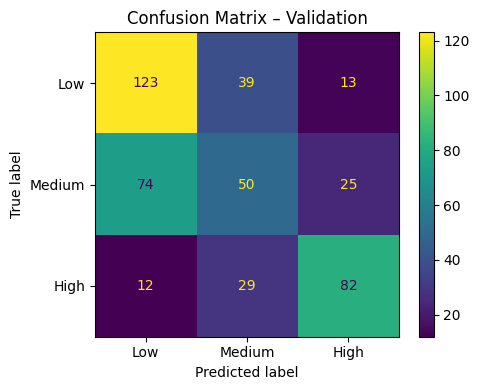


── Test ──
Accuracy: 0.5794
              precision    recall  f1-score   support

     Low (0)       0.58      0.62      0.60       174
  Medium (1)       0.45      0.36      0.40       149
    High (2)       0.69      0.78      0.73       124

    accuracy                           0.58       447
   macro avg       0.57      0.59      0.58       447
weighted avg       0.57      0.58      0.57       447



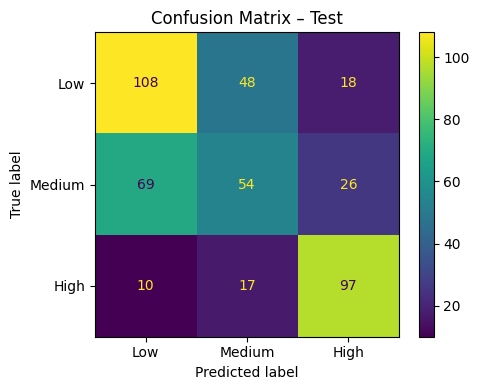

In [208]:
for split_name, X_sp, y_sp in [('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    y_pred = model_weighted.predict(X_sp)
    acc = accuracy_score(y_sp, y_pred)
    print(f"\n── {split_name} ──")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_sp, y_pred, target_names=['Low (0)', 'Medium (1)', 'High (2)']))
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_sp, y_pred,
        display_labels=['Low', 'Medium', 'High'],
        ax=ax
    )
    ax.set_title(f'Confusion Matrix – {split_name}')
    plt.tight_layout()
    plt.show()

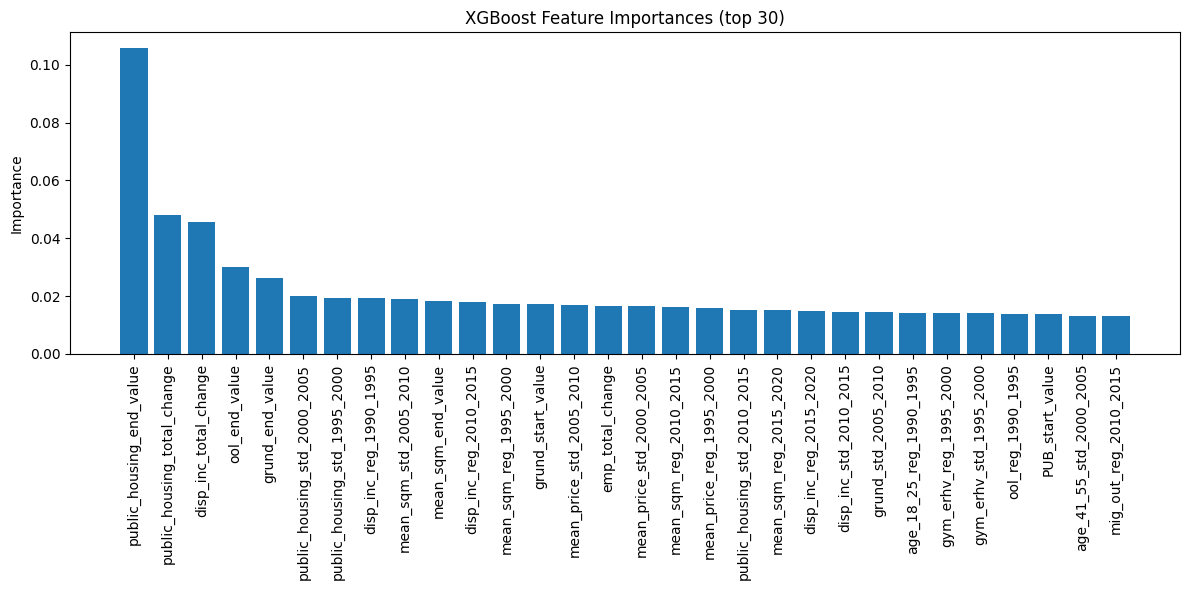

In [187]:
# Feature importance (top 30)
fi = model_weighted.feature_importances_
names = np.array(X.columns)
idx = np.argsort(fi)[::-1][:30]

plt.figure(figsize=(12, 6))
plt.bar(range(len(idx)), fi[idx], align='center')
plt.xticks(range(len(idx)), names[idx], rotation=90)
plt.ylabel('Importance')
plt.title('XGBoost Feature Importances (top 30)')
plt.tight_layout()
plt.show()

## 7b. Two-Stage Cascade Classifier

The confusion matrix shows **~69 Medium samples misclassified as Low** — a systematic Low/Medium boundary failure.
A single multiclass model shares the same probability space for both boundaries; a cascade separates them:

- **Stage 1** — binary: Low (0) vs Non-Low (1 or 2)
- **Stage 2** — binary: Medium (1) vs High (2), applied only to Stage-1 Non-Low predictions

Both stages reuse `best_params` from the hyperparameter search + early stopping. No extra tuning needed.


Stage 1 (Low vs Non-Low):  best trees = 14
  Val accuracy: 0.6913

Stage 2 (Medium vs High): best trees = 22
  Val accuracy: 0.7721

── Cascade Test Results ──
Accuracy:  Cascade=0.5996   Single=0.5526   Δ=+0.0470
              precision    recall  f1-score   support

     Low (0)       0.58      0.74      0.65       174
  Medium (1)       0.51      0.33      0.40       149
    High (2)       0.71      0.73      0.72       124

    accuracy                           0.60       447
   macro avg       0.60      0.60      0.59       447
weighted avg       0.59      0.60      0.58       447



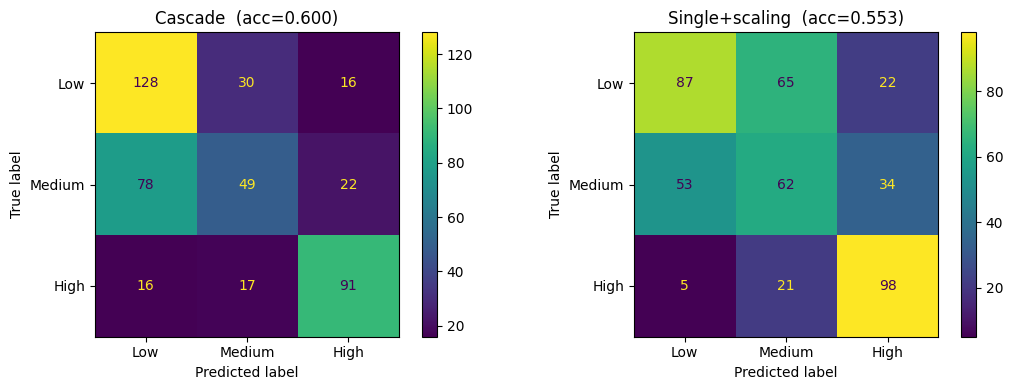

In [209]:
# Strip multiclass-specific params so binary stages don't inherit num_class / objective
_binary_params = {k: v for k, v in best_params.items()
                  if k not in ('num_class', 'objective')}

# ── Stage 1: Low (0) vs Non-Low (1 or 2) ────────────────────────────────────
y_train_s1 = (y_train > 0).astype(int)   # {0, 1}
y_val_s1   = (y_val   > 0).astype(int)
y_test_s1  = (y_test  > 0).astype(int)

cw_s1     = compute_class_weight('balanced', classes=np.unique(y_train_s1), y=y_train_s1)
cw_s1_map = dict(zip(np.unique(y_train_s1), cw_s1))
sw_s1     = np.array([cw_s1_map[yi] for yi in y_train_s1])

model_s1 = XGBClassifier(**_binary_params, n_estimators=1000,
                          early_stopping_rounds=20, random_state=42)
model_s1.fit(X_train, y_train_s1,
             eval_set=[(X_val, y_val_s1)],
             sample_weight=sw_s1, verbose=False)
print(f"Stage 1 (Low vs Non-Low):  best trees = {model_s1.best_iteration + 1}")
print(f"  Val accuracy: {accuracy_score(y_val_s1, model_s1.predict(X_val)):.4f}")

# ── Stage 2: Medium (1) vs High (2) — trained on Non-Low samples only ────────
# Remap {1, 2} → {0, 1} for XGBoost binary; prediction maps back to {1, 2}
mask_train_s2 = y_train > 0
X_train_s2    = X_train[mask_train_s2]
y_train_s2    = (y_train[mask_train_s2] - 1).astype(int)  # 1→0, 2→1

mask_val_s2 = y_val > 0
X_val_s2    = X_val[mask_val_s2]
y_val_s2    = (y_val[mask_val_s2] - 1).astype(int)        # 1→0, 2→1

cw_s2     = compute_class_weight('balanced', classes=np.unique(y_train_s2), y=y_train_s2)
cw_s2_map = dict(zip(np.unique(y_train_s2), cw_s2))
sw_s2     = np.array([cw_s2_map[yi] for yi in y_train_s2])

model_s2 = XGBClassifier(**_binary_params, n_estimators=1000,
                          early_stopping_rounds=20, random_state=42)
model_s2.fit(X_train_s2, y_train_s2,
             eval_set=[(X_val_s2, y_val_s2)],
             sample_weight=sw_s2, verbose=False)
print(f"\nStage 2 (Medium vs High): best trees = {model_s2.best_iteration + 1}")
# Val accuracy reported against original {1,2} labels
print(f"  Val accuracy: {accuracy_score(y_val[mask_val_s2], model_s2.predict(X_val_s2) + 1):.4f}")

# ── Cascade prediction ────────────────────────────────────────────────────────
def predict_cascade(X_in):
    """Stage 1 → Low or Non-Low; Stage 2 → Medium or High for Non-Low.
    Stage 2 outputs {0,1} which are mapped back to {1,2}.
    """
    stage1 = model_s1.predict(X_in)       # 0=Low, 1=Non-Low
    stage2 = model_s2.predict(X_in) + 1   # 0→1 (Medium), 1→2 (High)
    return np.where(stage1 == 0, 0, stage2)

# ── Test evaluation ───────────────────────────────────────────────────────────
y_test_casc = predict_cascade(X_test)
acc_casc    = accuracy_score(y_test, y_test_casc)

# Single-model baseline for direct comparison
scales_cmp    = _make_scales(best_s1, best_s2)
y_test_single = np.array([classes_list[i]
                           for i in np.argmax(model_weighted.predict_proba(X_test)
                                              * scales_cmp, axis=1)])
acc_single    = accuracy_score(y_test, y_test_single)

print(f"\n── Cascade Test Results ──")
print(f"Accuracy:  Cascade={acc_casc:.4f}   Single={acc_single:.4f}   Δ={acc_casc-acc_single:+.4f}")
print(classification_report(y_test, y_test_casc,
                             target_names=['Low (0)', 'Medium (1)', 'High (2)']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_casc, display_labels=['Low', 'Medium', 'High'], ax=axes[0])
axes[0].set_title(f'Cascade  (acc={acc_casc:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_single, display_labels=['Low', 'Medium', 'High'], ax=axes[1])
axes[1].set_title(f'Single+scaling  (acc={acc_single:.3f})')
plt.tight_layout()
plt.show()


## 8. Per-Class Probability Scaling (2-D Grid Search)

Grid-search scale factors `s1` (Medium) and `s2` (High) on the validation set, optimising `f1_macro`. Prediction rule:

$$\hat{y} = \arg\max_k \left( P(k \mid x) \cdot s_k \right), \quad s_0 = 1,\; s_1,\; s_2$$


Best scales:  s1=1.250 (Medium), s2=1.500 (High)
Val f1_macro: 0.5431

Validation report at best (s1, s2):
              precision    recall  f1-score   support

     Low (0)       0.58      0.55      0.56       175
  Medium (1)       0.40      0.36      0.38       149
    High (2)       0.62      0.76      0.69       123

    accuracy                           0.54       447
   macro avg       0.54      0.56      0.54       447
weighted avg       0.53      0.54      0.54       447



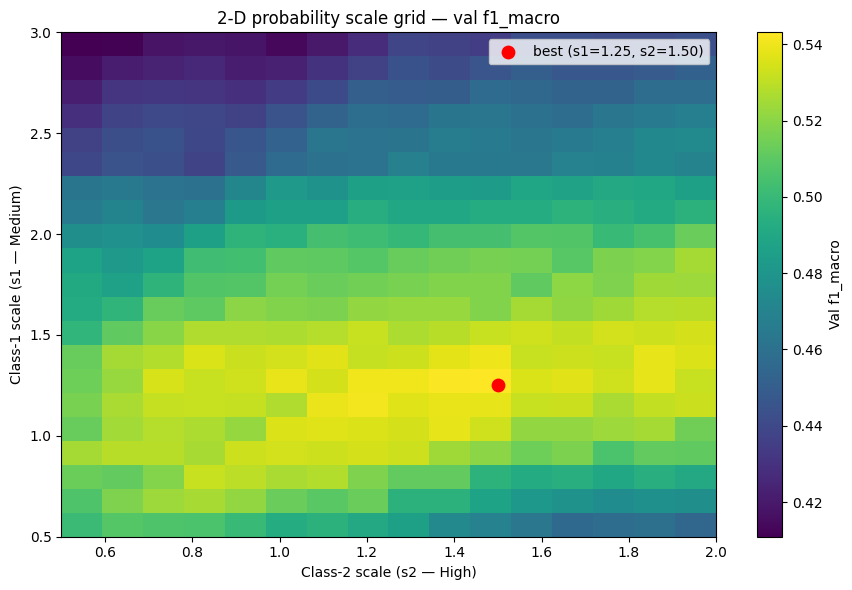

Saved: ../results/models\scale_sweep_2d.jpg

Using s1=1.250, s2=1.500 for downstream predictions.


In [198]:
# ── 2-D per-class probability scaling ────────────────────────────────────────
# predict = argmax(proba * [1.0, s1, s2])
# Grid-search (s1, s2) on validation set to maximise f1_macro.

proba_val_all  = model_weighted.predict_proba(X_val)
proba_test_all = model_weighted.predict_proba(X_test)

classes_list = list(getattr(model_weighted, 'classes_', np.array([0, 1, 2])))
idx_class0   = classes_list.index(0) if 0 in classes_list else 0
idx_class1   = classes_list.index(1) if 1 in classes_list else 1
idx_class2   = classes_list.index(2) if 2 in classes_list else 2

def _make_scales(s1, s2=1.0, n=len(classes_list)):
    scales = np.ones(n)
    scales[idx_class1] = s1
    scales[idx_class2] = s2
    return scales

# 2-D grid sweep
s1_grid = np.linspace(0.5, 3.0, 21)
s2_grid = np.linspace(0.5, 2.0, 16)

best_f1, best_s1, best_s2 = -1.0, 1.0, 1.0
f1_map = np.zeros((len(s1_grid), len(s2_grid)))

for i, s1 in enumerate(s1_grid):
    for j, s2 in enumerate(s2_grid):
        scales   = _make_scales(s1, s2)
        y_pred_s = np.array([classes_list[k]
                              for k in np.argmax(proba_val_all * scales, axis=1)])
        f1 = f1_score(y_val, y_pred_s, average='macro', zero_division=0)
        f1_map[i, j] = f1
        if f1 > best_f1:
            best_f1, best_s1, best_s2 = f1, float(s1), float(s2)

print(f"Best scales:  s1={best_s1:.3f} (Medium), s2={best_s2:.3f} (High)")
print(f"Val f1_macro: {best_f1:.4f}")

# Validation report at best (s1, s2)
scales_best  = _make_scales(best_s1, best_s2)
y_val_scaled = np.array([classes_list[k]
                          for k in np.argmax(proba_val_all * scales_best, axis=1)])
print("\nValidation report at best (s1, s2):")
print(classification_report(y_val, y_val_scaled,
                             target_names=['Low (0)', 'Medium (1)', 'High (2)']))

# Heatmap
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(
    f1_map, aspect='auto', origin='lower',
    extent=[s2_grid[0], s2_grid[-1], s1_grid[0], s1_grid[-1]],
    cmap='viridis'
)
ax.scatter([best_s2], [best_s1], color='red', s=80, zorder=5,
           label=f'best (s1={best_s1:.2f}, s2={best_s2:.2f})')
plt.colorbar(im, ax=ax, label='Val f1_macro')
ax.set_xlabel('Class-2 scale (s2 — High)')
ax.set_ylabel('Class-1 scale (s1 — Medium)')
ax.set_title('2-D probability scale grid — val f1_macro')
ax.legend()
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, 'scale_sweep_2d.jpg')
fig.savefig(plot_path, format='jpeg', dpi=300)
plt.show()
print(f"Saved: {plot_path}")

# Override here if needed:
# best_s1, best_s2 = 1.5, 1.0

print(f"\nUsing s1={best_s1:.3f}, s2={best_s2:.3f} for downstream predictions.")


Test evaluation at s1=1.125, s2=1.100:
              precision    recall  f1-score   support

     Low (0)       0.59      0.56      0.57       174
  Medium (1)       0.44      0.42      0.43       149
    High (2)       0.69      0.79      0.74       124

    accuracy                           0.57       447
   macro avg       0.57      0.59      0.58       447
weighted avg       0.57      0.57      0.57       447



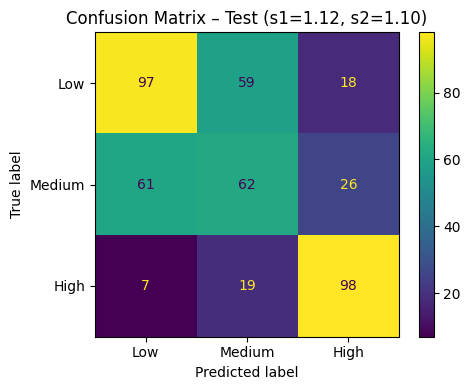

In [190]:
# Multiclass evaluation with 2-D per-class probability scaling
scales_best       = _make_scales(best_s1, best_s2)
y_test_pred_tuned = np.array([classes_list[i]
                               for i in np.argmax(proba_test_all * scales_best, axis=1)])

print(f"Test evaluation at s1={best_s1:.3f}, s2={best_s2:.3f}:")
print(classification_report(y_test, y_test_pred_tuned,
                             target_names=['Low (0)', 'Medium (1)', 'High (2)']))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_tuned,
    display_labels=['Low', 'Medium', 'High'], ax=ax
)
ax.set_title(f'Confusion Matrix – Test (s1={best_s1:.2f}, s2={best_s2:.2f})')
plt.tight_layout()
plt.show()


## 9. Save 2020 Predictions (Full Dataset)

In [191]:
# Apply 2-D per-class scaling to all clusters (not just test set)
proba_all   = model_weighted.predict_proba(X)
scales_best = _make_scales(best_s1, best_s2)
pred_all    = np.array([classes_list[i]
                        for i in np.argmax(proba_all * scales_best, axis=1)])

pred_df = pd.DataFrame({
    'cluster_id': data.loc[X.index, 'cluster_id'].values,
    'prediction': pred_all
})

out_path = os.path.join(RESULTS_DIR, 'predictions_cph.csv')
pred_df.to_csv(out_path, index=False)
print(f"Saved 2020 predictions: {out_path}  (rows={len(pred_df)})")
print(pred_df['prediction'].value_counts().sort_index())


Saved 2020 predictions: ../results/models\predictions_cph.csv  (rows=2232)
prediction
0    856
1    721
2    655
Name: count, dtype: int64


## 10. Future Predictions: 2025, 2030, 2035 !SKAL nok ikke bruges!

**Strategy: Probability-drift projection** — no feature manipulation. We work directly in the model's probability space.

**Why abandon feature manipulation?**  
All feature-shift variants distort the model's decision surface in ways the model never saw during training. The model doesn't reliably map "slope → 0" to Class 0; it uses a complex non-linear combination of all 60 features. Manipulating a subset creates unpredictable side effects.

**Mechanism:**  
The model already knows which neighbourhoods are *almost* Class 0 — they have high `P(class 0 | x)` but narrowly lose to class 1 or 2. Over time these should tip over. Each 5-year step, the non-Class-0 probability mass shrinks by `TRANSITION_FACTOR`:

$$p_0^{(t)} = 1 - (1 - p_0^{(2020)}) \cdot \delta^{t/5}$$
$$p_1^{(t)} = p_1^{(2020)} \cdot \frac{1 - p_0^{(t)}}{p_1^{(2020)} + p_2^{(2020)}}, \quad p_2^{(t)} \text{ analogously}$$

**Guarantees:**
- $p_0^{(t)}$ is **strictly non-decreasing** in $t$ — Class 0 can only grow, never shrink.
- The class 1 / class 2 ratio is preserved; they compete only for the remaining mass.
- No features are modified — the decision surface is respected.

`TRANSITION_FACTOR = 0.75` means 25% of non-Class-0 probability is transferred toward Class 0 each 5-year step (56% remaining at 2030, 42% at 2035).  
Tune toward 0.50 for faster growth, 0.90 for slower.


In [222]:
# ── Probability-drift future projection ───────────────────────────────────────
# Each 5-year step, (1 - p0) shrinks by TRANSITION_FACTOR.
# p0 grows monotonically → Class 0 count is GUARANTEED non-decreasing.
# Class 1/2 ratio is preserved as their combined mass shrinks.
# No features are modified.
TRANSITION_FACTOR = 0.75   # fraction of non-Class-0 mass retained per 5-year step

# 2020 baseline probabilities (frozen)
proba_base = model_weighted.predict_proba(X)   # shape (n_samples, 3)

p0_base = proba_base[:, idx_class0]
p1_base = proba_base[:, idx_class1]
p2_base = proba_base[:, idx_class2]

future_dfs = []

for year, t in FUTURE_HORIZONS.items():
    retention = TRANSITION_FACTOR ** (t / 5)   # shrinks with each horizon

    # ── Boost Class-0 probability ─────────────────────────────────────────────
    p0_new = 1.0 - (1.0 - p0_base) * retention   # strictly >= p0_base

    # ── Rescale Class 1 & 2 to fill remaining mass (preserve their ratio) ─────
    remaining  = 1.0 - p0_new
    rest_sum   = p1_base + p2_base
    safe_sum   = np.where(rest_sum > 0, rest_sum, 1.0)
    p1_new     = p1_base * (remaining / safe_sum)
    p2_new     = p2_base * (remaining / safe_sum)

    # ── Rebuild probability matrix and apply 2-D per-class scaling ────────────
    proba_future = np.zeros_like(proba_base)
    proba_future[:, idx_class0] = p0_new
    proba_future[:, idx_class1] = p1_new
    proba_future[:, idx_class2] = p2_new

    scales = np.ones(proba_future.shape[1])
    scales[idx_class1] = best_s1
    scales[idx_class2] = best_s2

    preds = np.array([classes_list[i]
                      for i in np.argmax(proba_future * scales, axis=1)])

    dist = dict(pd.Series(preds).value_counts().sort_index())
    print(f"{year} (t={t}y, non-class0 retained={retention:.3f}): {dist}")

    df_fut = pd.DataFrame({
        'cluster_id': data.loc[X.index, 'cluster_id'].values,
        'prediction': preds,
        'year': year
    })

    out_path = os.path.join(RESULTS_DIR, f'future_predictions_{year}.csv')
    df_fut[['cluster_id', 'prediction']].to_csv(out_path, index=False)
    print(f"  Saved: {out_path}")

    future_dfs.append(df_fut)

print("\nFuture prediction files saved.")


2025 (t=5y, non-class0 retained=0.750): {0: np.int64(1287), 1: np.int64(290), 2: np.int64(655)}
  Saved: ../results/models\future_predictions_2025.csv
2030 (t=10y, non-class0 retained=0.562): {0: np.int64(1802), 1: np.int64(1), 2: np.int64(429)}
  Saved: ../results/models\future_predictions_2030.csv
2035 (t=15y, non-class0 retained=0.422): {0: np.int64(2179), 2: np.int64(53)}
  Saved: ../results/models\future_predictions_2035.csv

Future prediction files saved.


## 11. Timeline Visualisation

Stacked bar chart showing how the class distribution evolves from 2020 → 2025 → 2030 → 2035.

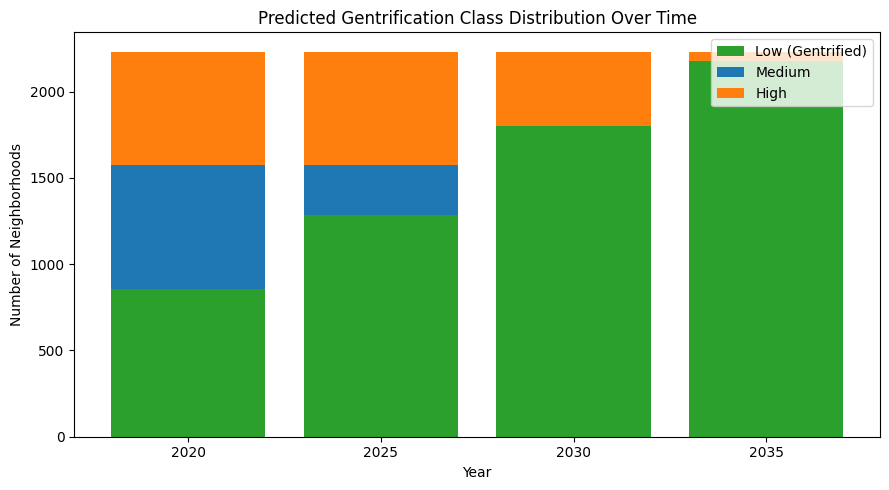

Saved timeline chart: ..\results\figures\gentrification_timeline.jpg

Class counts per year:
prediction  Low (Gentrified)  Medium  High
year                                      
2020                     856     721   655
2025                    1287     290   655
2030                    1802       1   429
2035                    2179       0    53


In [223]:
# Combine 2020 baseline + future predictions
df_2020 = pred_df.copy()
df_2020['year'] = 2020

timeline = pd.concat([df_2020] + future_dfs, ignore_index=True)

# Count per year × class
counts = (
    timeline
    .groupby(['year', 'prediction'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1, 2], fill_value=0)
)

# Stacked bar chart
class_labels = {0: 'Low (Gentrified)', 1: 'Medium', 2: 'High'}
colors = {0: '#2ca02c', 1: '#1f77b4', 2: '#ff7f0e'}

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(counts))
x = np.arange(len(counts))

for cls in [0, 1, 2]:
    vals = counts[cls].values if cls in counts.columns else np.zeros(len(counts))
    ax.bar(x, vals, bottom=bottom, label=class_labels[cls], color=colors[cls])
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(counts.index.astype(str))
ax.set_xlabel('Year')
ax.set_ylabel('Number of Neighborhoods')
ax.set_title('Predicted Gentrification Class Distribution Over Time')
ax.legend(loc='upper right')
plt.tight_layout()

fig_path = os.path.join('..', 'results', 'figures', 'gentrification_timeline.jpg')
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
fig.savefig(fig_path, format='jpeg', dpi=300)
plt.show()
print(f"Saved timeline chart: {fig_path}")
print("\nClass counts per year:")
print(counts.rename(columns=class_labels))